In [1]:
# Cell 1 — Imports & parameters
import re, csv, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Parameters you can change
ARFF_PATH = "dataset.arff"   # path to your ARFF (already uploaded here)
TS_COLUMN = "PM2.5"     
ARIMA_P_RANGE = range(0,3)  #(p,d,q)
ARIMA_D_RANGE = range(0,2)  
ARIMA_Q_RANGE = range(0,3)  
MAX_ARIMA_FITS = 50         #Stops after fitting 50 models
SEASONAL_PERIOD_FALLBACK = 12 
#plt.rcParams['figure.figsize'] = (9,4)

In [2]:
from arff_csv import arff_to_csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as sts
import seaborn as sns
sns.set_style('darkgrid')

In [20]:
#Loading data 
# Load dataset
df = pd.read_csv("dataset.csv")

display(df.head())
display(df.describe().T)
display((df.isnull().sum() / len(df) * 100).to_frame("Missing %"))

df.info()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


,count,mean,std,min,25%,50%,75%,max
No,420768.0,17532.500000,10122.116943,1.0000,8766.75,17532.5,26298.25,35064.0
year,420768.0,2014.662560,1.177198,2013.0000,2014.00,2015.0,2016.00,2017.0
month,420768.0,6.522930,3.448707,1.0000,4.00,7.0,10.00,12.0
day,420768.0,15.729637,8.800102,1.0000,8.00,16.0,23.00,31.0
hour,420768.0,11.500000,6.922195,0.0000,5.75,11.5,17.25,23.0
PM2.5,412029.0,79.793428,80.822391,2.0000,20.00,55.0,111.00,999.0
PM10,414319.0,104.602618,91.772426,2.0000,36.00,82.0,145.00,999.0
SO2,411747.0,15.830835,21.650603,0.2856,3.00,7.0,20.00,500.0
NO2,408652.0,50.638586,35.127912,1.0265,23.00,43.0,71.00,290.0
CO,400067.0,1230.766454,1160.182716,100.0000,500.00,900.0,1500.00,10000.0


,Missing %
No,0.000000
year,0.000000
month,0.000000
day,0.000000
hour,0.000000
PM2.5,2.076916
PM10,1.532674
SO2,2.143937
NO2,2.879497
CO,4.919813


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


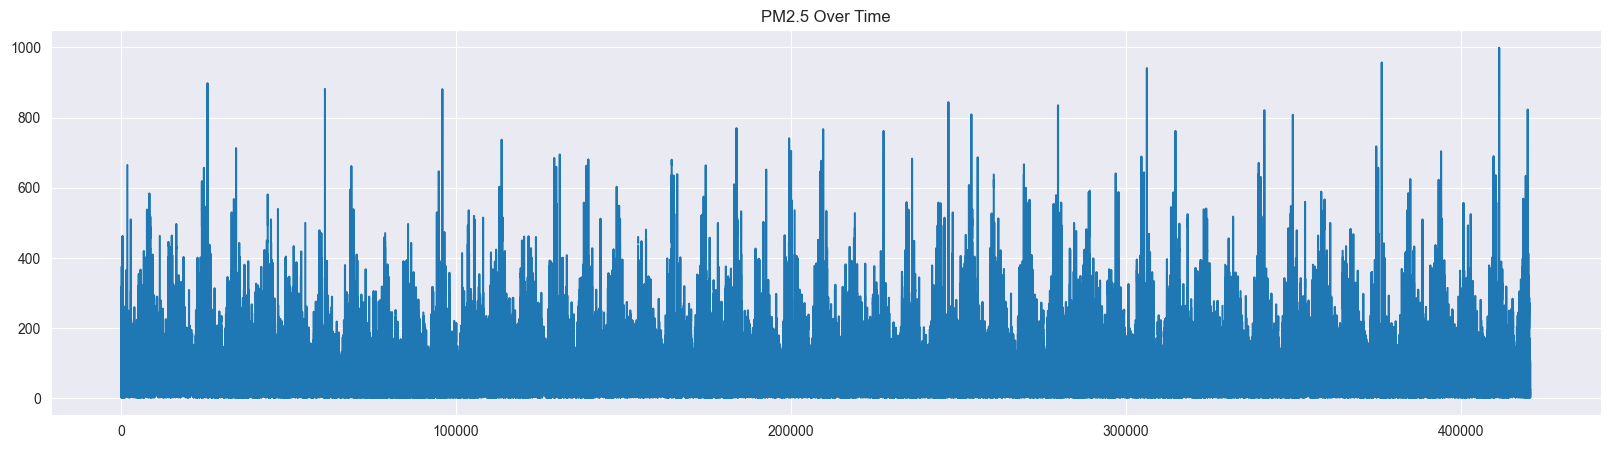

In [21]:
df['PM2.5'].plot(title='PM2.5 Over Time', figsize=(20, 5))
plt.show()

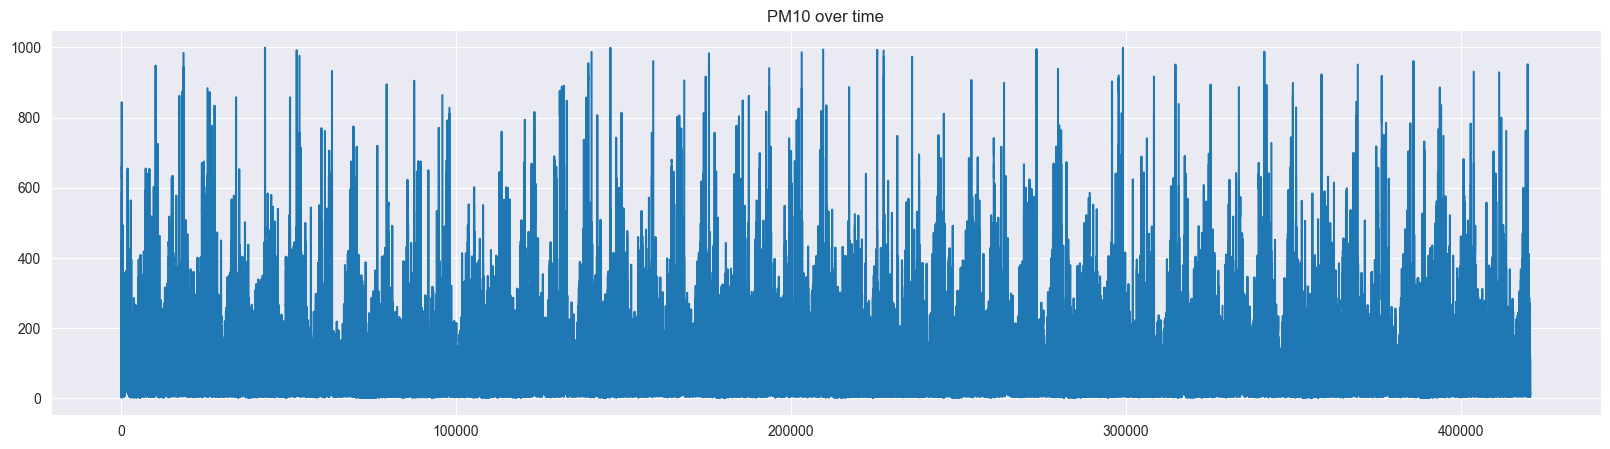

In [22]:
df.PM10.plot(title="PM10 over time", figsize=(20, 5))
plt.show()

In [31]:
# tells Pandas and the forecasting models that your data is ordered by time.
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.sort_values('datetime')

df.set_index('datetime', inplace=True)

In [32]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
obj_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numeric columns:", num_cols)
print("Object columns:", obj_cols)

Numeric columns: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
Object columns: ['wd', 'station']


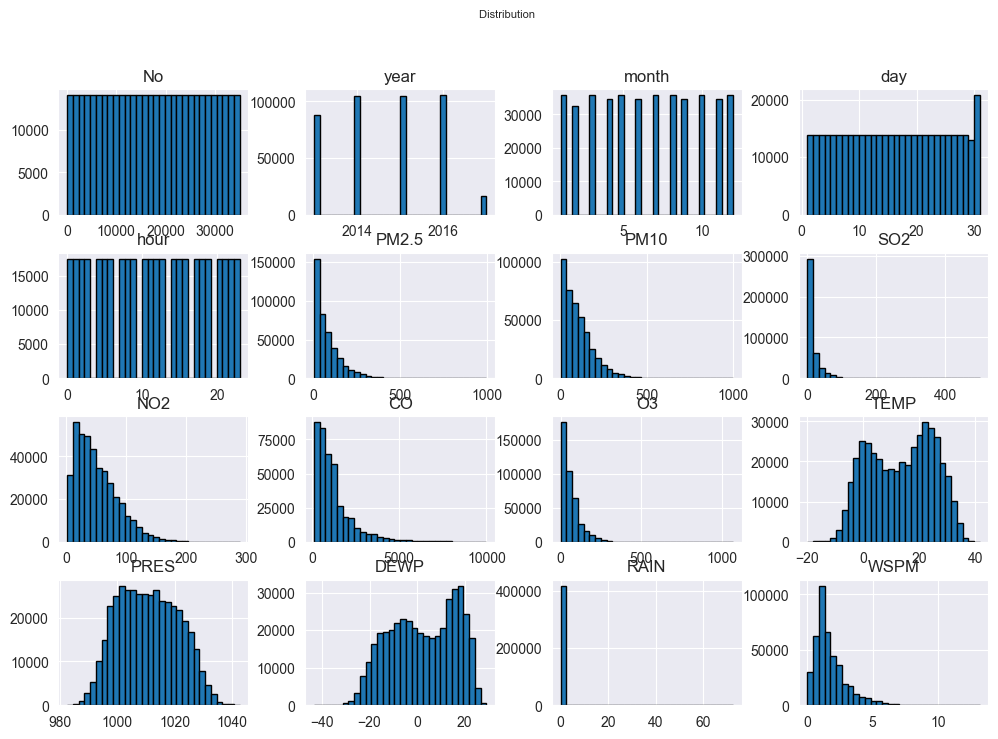

In [6]:
# Histograms
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df[num_cols].hist(figsize=(12, 8), bins=30, edgecolor="black")
plt.suptitle("Distribution ", fontsize=8)
plt.show()

In [ ]:
# Histograms for numeric columns
# for c in num_cols:
#     plt.figure()
#     df[c].dropna().plot(kind='hist', bins=30)
#     plt.title(f"Histogram: {c}")
#     plt.xlabel(c)
#     plt.tight_layout()
#     plt.show()

# # Missing-value map
# plt.figure(figsize=(10, max(3, len(df.columns)*0.3)))
# plt.imshow(df.isna().T, aspect='auto', interpolation='none')
# plt.yticks(range(len(df.columns)), df.columns)
# plt.title("Missing-value map (columns on y-axis)")
# plt.xlabel("Row index")
# plt.tight_layout()
# plt.show()

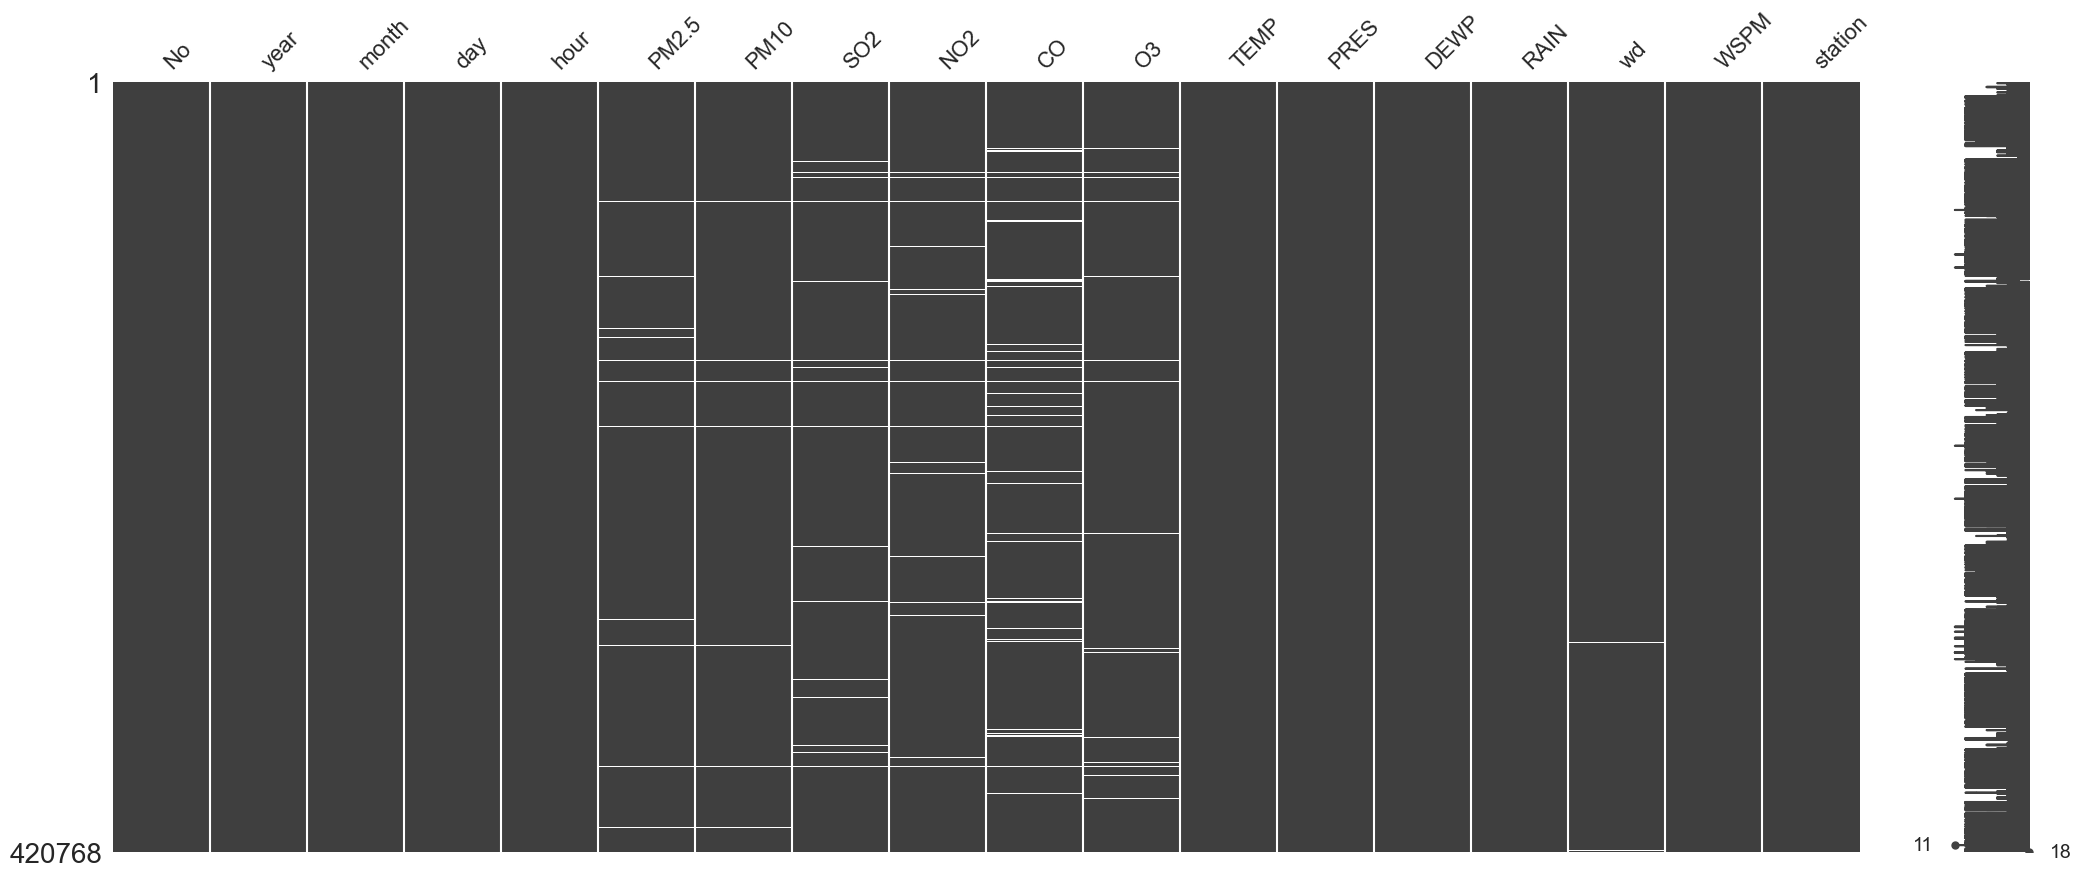

In [5]:
import missingno as msno
msno.matrix(df)
plt.show()

In [33]:
# Cell 4 — Fill missing values (ffill + fallback bfill) and save
#df_filled = df.fillna(method='ffill')
df_filled = df.ffill().bfill()
display(Markdown("Missing per column before fill"))
display(df.isna().sum()[df.isna().sum()>0])
#display(Markdown("Missing per column after ffill/bfill"))
#display(df_filled.isna().sum()[df_filled.isna().sum()>0] if df_filled.isna().sum().sum()>0 else "No missing values remain")

Missing per column before fill

PM2.5     8739
PM10      6449
SO2       9021
NO2      12116
CO       20701
O3       13277
TEMP       398
PRES       393
DEWP       403
RAIN       390
wd        1822
WSPM       318
dtype: int64

In [34]:
df_filled.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

Chooses a numeric column to forecast.
Searches for a date/time column.
Converts it into a datetime index.
Sorts observations chronologically.
Extracts one clean numeric series.
Produces a series object ready for stationarity tests, ARIMA/SARIMA, Prophet, or LSTM training.

In [ ]:
# TS_COLUMN = 'PM2.5'

# series = pd.to_numeric(df_filled[TS_COLUMN], errors='coerce').dropna()

# print("Using series:", TS_COLUMN)
# display(series.head())

Using series: PM2.5


0    4.0
1    8.0
2    7.0
3    6.0
4    3.0
Name: PM2.5, dtype: float64

In [35]:
#Prep a single time series -decides which column will be analyzed.
if TS_COLUMN is None:
    if len(num_cols) == 0:
        raise RuntimeError("No numeric columns")
    ts_col = num_cols[0]
else:
    ts_col = TS_COLUMN
print("Using series:", ts_col)

# Try to find a datetime column as index
dt_candidates = [c for c in df_filled.columns if 'date' in str(c).lower() or 'time' in str(c).lower()]
datetime_index_col = None
for c in dt_candidates:
    parsed = pd.to_datetime(df_filled[c], errors='coerce', infer_datetime_format=True)
    if parsed.notna().sum()>0:
        df_filled[c+'_parsed'] = parsed
        datetime_index_col = c+'_parsed'
        break

if datetime_index_col:
    ts_df = df_filled.set_index(datetime_index_col).sort_index()
    print("Using datetime index:", datetime_index_col)
else:
    ts_df = df_filled.copy()
    ts_df.index = pd.RangeIndex(len(ts_df))
    print("No datetime index detected; using integer index (assumes evenly spaced observations).")

series = pd.to_numeric(ts_df[ts_col], errors='coerce').dropna() #Converts values to numbers - Remove invalid rows.
display(series.head())

Using series: PM2.5
No datetime index detected; using integer index (assumes evenly spaced observations).


0    4.0
1    6.0
2    4.0
3    8.0
4    3.0
Name: PM2.5, dtype: float64

In [36]:
df_filled.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,,
2013-03-01,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
2013-03-01,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
2013-03-01,1,2013,3,1,0,4.0,4.0,3.0,8.0,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
2013-03-01,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
2013-03-01,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping


In [37]:
print(series.index[:10])

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')


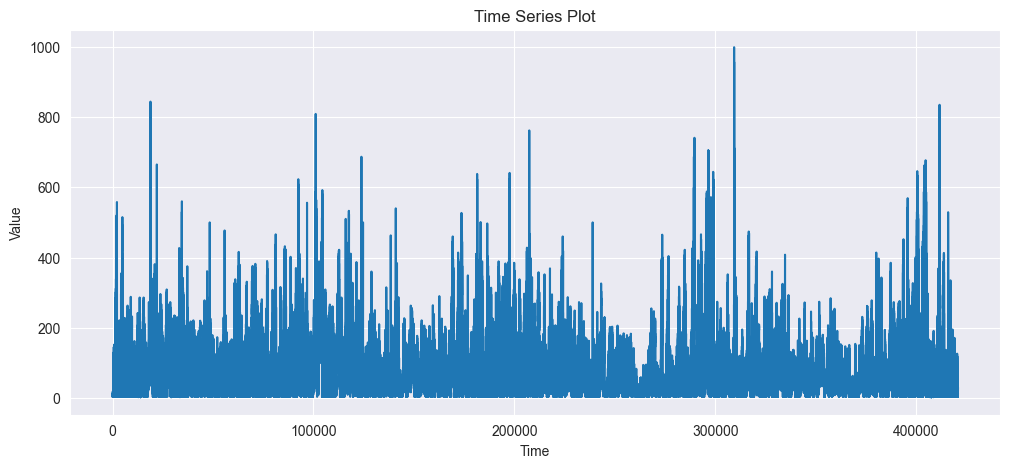

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(series)
plt.title("Time Series Plot")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [40]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(series.dropna())

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

for key, value in result[4].items():
    print(f"Critical Value ({key}): {value:.4f}")

if result[1] < 0.05:
    print("\nResult: Series is stationary (reject H₀)")
else:
    print("\nResult: Series is non-stationary (fail to reject H₀)")

ADF Statistic: -24.5743
p-value: 0.0000
Critical Value (1%): -3.4304
Critical Value (5%): -2.8615
Critical Value (10%): -2.5668

Result: Series is stationary (reject H₀)


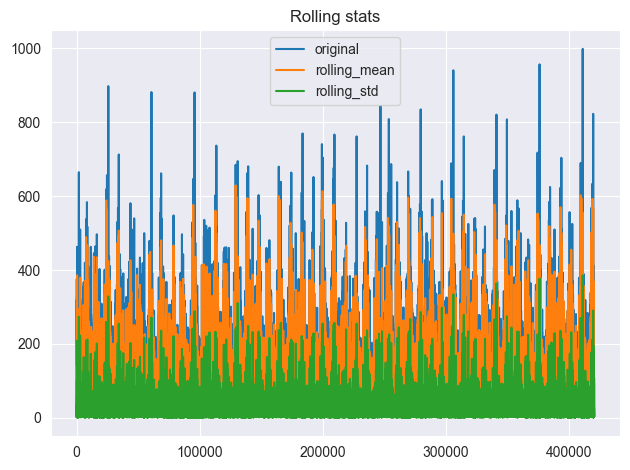

In [17]:

#stationarity check: ADF test + rolling stats
# from statsmodels.tsa.stattools import adfuller

# adf_res = adfuller(series, autolag='AIC') #choose the best one using AIC
# print("ADF statistic:", adf_res[0])
# print("p-value:", adf_res[1])
# print("usedlag:", adf_res[2])
# for k, v in adf_res[4].items():
#     print("Critical value (", k, "):", v)

# Rolling mean/std
window = min(12, max(1, len(series)//10))
rolling_mean = series.rolling(window=window).mean()
rolling_std = series.rolling(window=window).std()

plt.figure()
plt.plot(series, label='original')
plt.plot(rolling_mean, label='rolling_mean')
plt.plot(rolling_std, label='rolling_std')
plt.legend()
plt.title("Rolling stats")
plt.tight_layout()
plt.show()



Likely stationary - ADF p < 0.05.
-52 < -3.43 strong evidence against a unit root.
ARIMA(p,0,q)

In [41]:
series.head()

0    4.0
1    6.0
2    4.0
3    8.0
4    3.0
Name: PM2.5, dtype: float64

In [42]:
df_filled.index.value_counts().head(10)

datetime
2013-03-01 00:00:00    12
2013-03-01 01:00:00    12
2013-03-01 02:00:00    12
2013-03-01 03:00:00    12
2013-03-01 04:00:00    12
2013-03-01 05:00:00    12
2013-03-01 06:00:00    12
2013-03-01 07:00:00    12
2013-03-01 08:00:00    12
2013-03-01 09:00:00    12
Name: count, dtype: int64

Using period: 12


Seasonal component (first rows)

,observed,trend,seasonal,resid
0,4.0,5.232372,0.157658,-1.390030
1,6.0,5.331731,-0.032049,0.700318
2,4.0,5.431090,-0.055421,-1.375669
3,8.0,5.530449,-0.180221,2.649772
4,3.0,5.629808,-0.141813,-2.487995


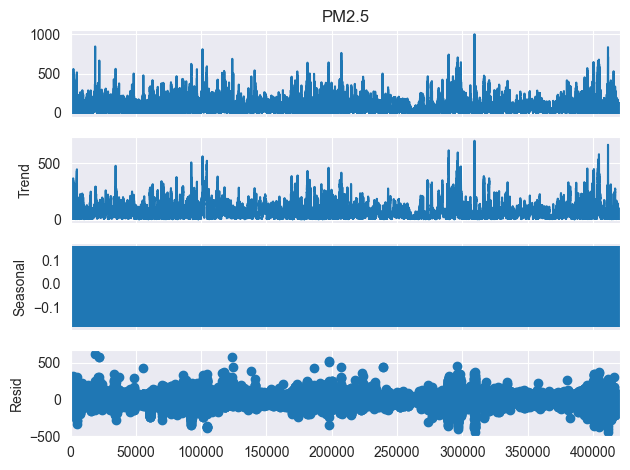

In [43]:
# Seasonality check (seasonal_decompose best-effort)
#Trend	Long-term direction (up/down)
#Seasonal	Repeating pattern (daily, weekly, yearly)
#Residual	Random noise
from statsmodels.tsa.seasonal import seasonal_decompose

# infer period
period = None
if hasattr(ts_df.index, 'inferred_freq') and ts_df.index.inferred_freq: #hecks if pandas knows your time spacing.
    freq = pd.tseries.frequencies.to_offset(ts_df.index.inferred_freq).name
    if 'D' in freq:
        period = 7
    elif 'M' in freq:
        period = 12
    elif 'H' in freq:
        period = 24
if period is None:
    period = SEASONAL_PERIOD_FALLBACK if len(series) > 24 else 1 #if frequency is unknown - use default

print("Using period:", period)
if period > 1 and len(series) > period*2:
    try:
        decomposition = seasonal_decompose(series, period=period, model='additive', extrapolate_trend='freq')
        display(Markdown("Seasonal component (first rows)"))
        display(pd.DataFrame({
            'observed': decomposition.observed.head(),
            'trend': decomposition.trend.head(),
            'seasonal': decomposition.seasonal.head(),
            'resid': decomposition.resid.head()
        }))
        decomposition.plot()
    except Exception as e:
        print("seasonal_decompose failed:", e)
else:
    print("Skipping seasonal decomposition (no clear seasonality or series too short).")


#Tries to guess season length (hourly/daily/monthly)- Splits your time series into: trend, seasonality, noise.
#Plots and displays.

<Figure size 640x480 with 0 Axes>

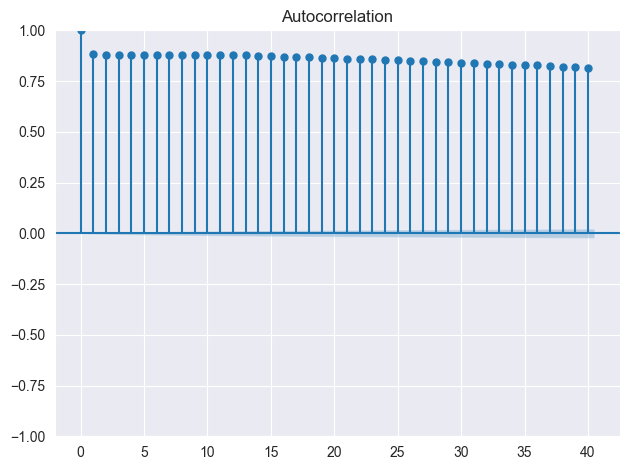

<Figure size 640x480 with 0 Axes>

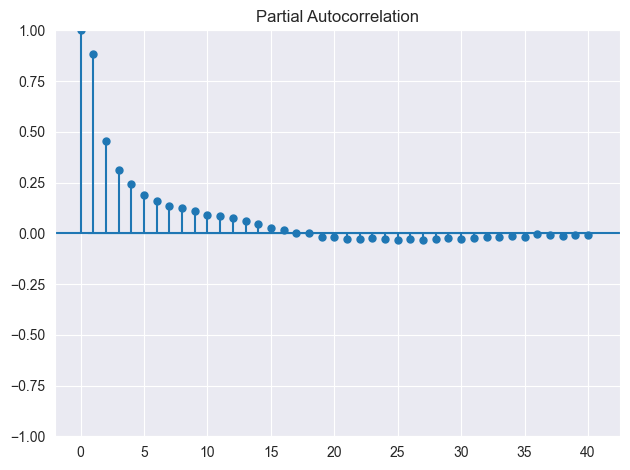

In [44]:
# ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure()
plot_acf(series, lags=min(40, len(series)-1))
plt.tight_layout()
plt.show()

plt.figure()
plot_pacf(series, lags=min(40, len(series)-1), method='ywm')
plt.tight_layout()
plt.show()

In [45]:
# Cell 9 — Grid search for ARIMA (p,d,q) by AIC — light search by default
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time

candidates = list(itertools.product(ARIMA_P_RANGE, ARIMA_D_RANGE, ARIMA_Q_RANGE))
results = []
start = time.time()
fit_count = 0

for order in candidates:
    if fit_count >= MAX_ARIMA_FITS:
        break
    p,d,q = order
    try:
        model = SARIMAX(series, order=(p,d,q), enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        results.append(((p,d,q), res.aic))
        fit_count += 1
    except Exception as e:
        # skip bad combinations
        continue

if not results:
    print("No ARIMA models fit successfully in this grid.")
else:
    results_sorted = sorted(results, key=lambda x: x[1])
    print("Top candidates by AIC:")
    for order, aic in results_sorted[:5]:
        print(order, "AIC:", aic)
    best_order, best_aic = results_sorted[0]
    print("Best order:", best_order, "AIC:", best_aic)

c:\Users\ecbas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Top candidates by AIC:
(2, 1, 2) AIC: 4031012.129875486
(2, 1, 1) AIC: 4039847.5805619005
(1, 0, 2) AIC: 4040352.529128732
(2, 0, 1) AIC: 4040377.549451211
(0, 1, 2) AIC: 4040476.0182493883
Best order: (2, 1, 2) AIC: 4031012.129875486


In [46]:
# 
if results:
    best_order = results_sorted[0][0]
    model = SARIMAX(series, order=best_order, enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    display(Markdown("**Model summary (trimmed)**"))
    print(res.summary())
    print("AIC:", res.aic)
    # display(Markdown("**Diagnostics plots**"))
    # res.plot_diagnostics(figsize=(12,8))
    # plt.tight_layout()
    # plt.show()
    # print("Check residuals: should resemble white noise (no autocorrelation).")

c:\Users\ecbas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**Model summary (trimmed)**

                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:               420768
Model:               SARIMAX(2, 1, 2)   Log Likelihood            -2015501.065
Date:                Thu, 04 Jun 2026   AIC                        4031012.130
Time:                        11:44:37   BIC                        4031066.879
Sample:                             0   HQIC                       4031027.741
                             - 420768                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9468      0.001   1253.908      0.000       0.945       0.948
ar.L2         -0.0479      0.001    -78.567      0.000      -0.049      -0.047
ma.L1         -1.8533      0.001  -3532.259      0.0

The model predicts PM2.5 using the last 2 values and last 2 errors, after removing trend via differencing.

In [20]:


# print("Automated conclusions & suggestions:")
# if adf_res[1] < 0.05:
#     print("- Series appears stationary according to ADF (p < 0.05).")
# else:
#     print("- Series appears non-stationary according to ADF (p >= 0.05). Consider first-differencing (d=1).")

# print(f"- ARIMA search suggested best order {best_order} with AIC {best_aic:.2f} (among search grid).")
# print("- Next steps: validate residuals; if seasonal patterns exist, consider SARIMA with seasonal_order.")
# print("- If multiple numeric series present, repeat time-series analysis per series or build multivariate models.")

#### Model-Specific Preparation

In [47]:
# Prophet
prophet_df = df_filled.reset_index()[['datetime','PM2.5']]
prophet_df.columns = ['ds','y']

In [48]:
#LSTM
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_filled[['PM2.5']])

In [49]:
# This function converts a time series into a format that an LSTM, GRU, or other sequence model can learn from
def create_sequences(data, window=24):

    X, y = [], []

    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [50]:
df_filled['target'] = df['PM2.5'].shift(-1)
df.dropna(inplace=True)
#Current hour → Features
#Next hour → Target

Train/Test split

In [55]:
split = int(len(df_filled)*0.8)

train = df_filled[:split]
test = df_filled[split:]

In [56]:
#### Feature Selection

features = [col for col in df_filled.columns
            if col not in ['target']]

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

In [58]:
# ARIMA Training
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    y_train,
    order=(2,1,2)
)

arima_model = model.fit()

pred = arima_model.forecast(
    steps=len(test)
)

c:\Users\ecbas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ecbas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ecbas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ecbas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is ava

In [59]:
# SARIMA Training
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    y_train,
    order=(2,1,2),
    seasonal_order=(1,1,1,12)
).fit()

pred = sarima_model.forecast(
    len(test)
)

c:\Users\ecbas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ecbas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ecbas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ecbas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the 

In [60]:
pred = pred[:len(test)]
pred.index = test.index

In [65]:
test = y_test.copy()
pred = pd.Series(pred, index=test.index)

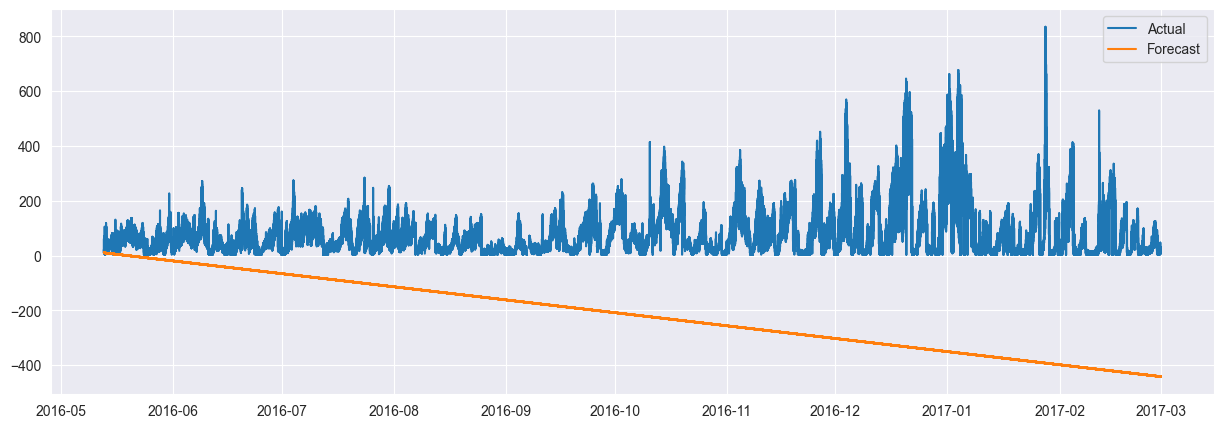

In [66]:
plt.figure(figsize=(15,5))
plt.plot(test, label="Actual")
plt.plot(pred, label="Forecast")
plt.legend()
plt.show()

In [70]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

ValueError: Input contains NaN.